# 사진 → 감정 → 이모지 매칭 파이프라인

**최종 목표**: 사진 속 인물의 표정을 읽어 **그 사람에게 맞는 이모지를 찾아주는 것.**

2023년 과제의 원래 구상은 4단계였다.

| 단계 | 내용 | 상태 |
|---|---|---|
| 0 | 사진으로 **나만의 이모티콘을 생성**하는 모델 | 학습 데이터 한계로 축소 판단 |
| 1 | 사진 → **표정 분류** (7개 감정) | ✅ CNN 학습 완료 (검증 정확도 0.5628) |
| 2 | 분류 결과 → **감정 수치화** | §3 — 이미 되어 있었다 |
| 3 | 수치 → **대응하는 기본 이모지 할당** | §2·§4 — 이 노트북에서 완성 |

당시 3단계에서 막혔다. 기본 이모지의 표정을 분류하려고 **학습한 CNN을 이모지 이미지에 돌리려 했는데**,
그 전에 이모지를 이미지로 바꾸는 코드가 흰 이미지만 만들어내면서 거기서 끝났다.

이 노트북은 **그 접근 자체가 필요 없었다는 것**을 보이고, 필요한 것으로 3단계를 완성한다.

> 목표 0(생성)과 목표 3(할당)은 다른 문제다. 사진에서 **새로운** 이모지를 만들어내려면
> (사진, 그에 대응하는 맞춤 이모지) 쌍 데이터가 대량으로 있어야 하는데 그런 데이터셋은 없다.
> 기존 이모지 중에서 **골라주는 것**(retrieval)이 같은 목적을 이루는 실행 가능한 형태이고,
> 위 1~3단계가 정확히 그것이다. 당시의 축소 판단은 옳았다.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

plt.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
FER = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
print('7개 클래스:', FER)

7개 클래스: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 1. 원래 접근이 왜 성립하지 않았는가

계획은 **"이모지를 48×48 이미지로 바꿔서 CNN에 넣고 감정 레이블을 받는다"** 였다.
이모지 변환 버그를 고친 뒤 실제로 넣어봤다면 어떻게 됐을지, 입력의 성질로 확인한다.

In [2]:
FONT = '/System/Library/Fonts/Apple Color Emoji.ttc'
font = ImageFont.truetype(FONT, 160)

def render(ch, target=48):
    im = Image.new('RGB', (160, 160), 'white')
    d = ImageDraw.Draw(im)
    b = d.textbbox((0, 0), ch, font=font, embedded_color=True)
    d.text((-b[0], -b[1]), ch, font=font, embedded_color=True)
    return im.resize((target, target), Image.LANCZOS)

g = np.array(render('😀').convert('L'))
print(f'이모지 48×48 그레이스케일 — 평균 {g.mean():.1f}, 표준편차 {g.std():.1f}')
print(f'순백(255) 픽셀 비율: {(g == 255).mean()*100:.1f}%')
print(f'고유 픽셀값 개수: {len(np.unique(g))} / 256')
print()
print('FER 학습 데이터는 사람 얼굴 사진이다 — 자연광, 다양한 각도, 연속적인 명암 계조.')
print('형식(48×48 그레이스케일)만 같을 뿐 픽셀 분포가 전혀 다른 입력이다.')

이모지 48×48 그레이스케일 — 평균 207.1, 표준편차 51.4
순백(255) 픽셀 비율: 26.3%
고유 픽셀값 개수: 191 / 256

FER 학습 데이터는 사람 얼굴 사진이다 — 자연광, 다양한 각도, 연속적인 명암 계조.
형식(48×48 그레이스케일)만 같을 뿐 픽셀 분포가 전혀 다른 입력이다.


사람 얼굴 사진에서 학습한 필터가 이런 입력에서 의미 있는 특징을 뽑을 이유가 없다.
**도메인이 다르기 때문에, 버그를 고쳤어도 이 경로는 신뢰할 수 없는 레이블을 만들었을 것이다.**

그런데 더 근본적인 문제가 있다.

## 2. 이모지는 이미 레이블을 갖고 있다

`emoji_df.csv`를 열어보면 답이 옆 칸에 있다.

In [3]:
emoji_df = pd.read_csv('emoji_df.csv')
print(f'전체 {len(emoji_df)}개, 컬럼: {list(emoji_df.columns)}')
print()
print(emoji_df.head(3).to_string(index=False))

전체 4724개, 컬럼: ['emoji', 'name', 'group', 'sub_group', 'codepoints']

emoji                            name             group    sub_group codepoints
    😀                   grinning face Smileys & Emotion face-smiling      1F600
    😃     grinning face with big eyes Smileys & Emotion face-smiling      1F603
    😄 grinning face with smiling eyes Smileys & Emotion face-smiling      1F604


`name`과 `sub_group` 컬럼이 있다. 그리고 원본이 선택한 범위를 다시 보자.

In [4]:
sel = emoji_df.iloc[0:105].reset_index(drop=True)      # 원본과 동일한 선택
print('원본 코드: selected_data = emoji_df.iloc[0:105, 0]')
print()
face_rows = emoji_df[emoji_df.sub_group.str.startswith('face-')]
print(f"선택된 105개가 전부 'face-' sub_group인가: {sel.sub_group.str.startswith('face-').all()}")
print(f"전체 'face-' 블록: 인덱스 {face_rows.index.min()} ~ {face_rows.index.max()} ({len(face_rows)}개)")
print(f"→ 105에서 잘라 뒤쪽 {len(face_rows)-105}개를 제외했다.")
print()
print('제외된 105~118:')
for i in range(105, 119):
    print(f"    {emoji_df.emoji[i]} {emoji_df['name'][i]:30} [{emoji_df.sub_group[i]}]")
print()
print(f"얼굴 블록 직후 119번: {emoji_df.emoji[119]} {emoji_df['name'][119]} [{emoji_df.sub_group[119]}]")

원본 코드: selected_data = emoji_df.iloc[0:105, 0]

선택된 105개가 전부 'face-' sub_group인가: True
전체 'face-' 블록: 인덱스 0 ~ 118 (119개)
→ 105에서 잘라 뒤쪽 14개를 제외했다.

제외된 105~118:
    🤬 face with symbols on mouth     [face-negative]
    😈 smiling face with horns        [face-negative]
    👿 angry face with horns          [face-negative]
    💀 skull                          [face-negative]
    ☠️ skull and crossbones           [face-negative]
    ☠ skull and crossbones           [face-negative]
    💩 pile of poo                    [face-costume]
    🤡 clown face                     [face-costume]
    👹 ogre                           [face-costume]
    👺 goblin                         [face-costume]
    👻 ghost                          [face-costume]
    👽 alien                          [face-costume]
    👾 alien monster                  [face-costume]
    🤖 robot                          [face-costume]

얼굴 블록 직후 119번: 😺 grinning cat [cat-face]


**`iloc[0:105]`는 임의로 자른 숫자가 아니다.**

선택된 105개는 전부 `face-` sub_group이고, 잘라낸 자리가 의미를 갖는다.
제외된 105~118은 🤬😈👿💀☠️ 와 💩🤡👹👺👻👽👾🤖 — **해골·악마·광대·유령·외계인·로봇** 등
사람의 표정이 아닌 얼굴이고, 그 다음 119번부터는 고양이 얼굴이 시작된다.

즉 **사람 표정 이모지만 골라낸 선택**이었다.
(엄밀히는 🤬 `face with symbols on mouth` 하나는 사람 표정인데 함께 잘렸다.)

**데이터를 고른 판단은 처음부터 옳았다. 틀린 것은 그 데이터를 쓰는 방법이었다.**

그리고 이름을 보면 —

In [5]:
for sg in ['face-smiling', 'face-negative', 'face-concerned']:
    r = sel[sel.sub_group == sg]
    print(f'[{sg}] {len(r)}개')
    print('  ' + '  '.join(f'{e} {n}' for e, n in list(zip(r.emoji, r['name']))[:6]))
    print()

[face-smiling] 14개
  😀 grinning face  😃 grinning face with big eyes  😄 grinning face with smiling eyes  😁 beaming face with smiling eyes  😆 grinning squinting face  😅 grinning face with sweat

[face-negative] 3개
  😤 face with steam from nose  😡 enraged face  😠 angry face

[face-concerned] 27개
  😕 confused face  🫤 face with diagonal mouth  😟 worried face  🙁 slightly frowning face  ☹️ frowning face  ☹ frowning face



`angry face`, `fearful face`, `crying face`, `neutral face`, `astonished face`, `nauseated face` —
**FER 7개 클래스의 이름이 그대로 들어 있다.**

이모지에 CNN을 돌려서 얻으려던 레이블은, **CSV의 바로 옆 칸에 이미 있었다.**
필요한 것은 모델이 아니라 **대응표**였다.

## 3. 매핑표 만들기

`sub_group`이 아니라 `name`의 키워드로 매핑한다. `sub_group`은 FER 클래스와 경계가 맞지 않기 때문이다.

- `face-concerned`(27개)는 **sad · fearful · surprised 세 클래스에 걸쳐 있다** (😢 vs 😨 vs 😲)
- `face-unwell`(12개)은 대부분 FER 감정이 아니다 (😷🤒🤕🥵🥶) — 🤢🤮 만 disgusted
- `face-neutral-skeptical`(15개)에는 😏😒🙄 처럼 neutral이 아닌 것이 섞여 있다

규칙은 아래 표에 전부 드러난다. 위에서부터 먼저 걸리는 규칙이 이긴다
(예: `frowning face with open mouth` 😦 는 `frowning`이 `open mouth`보다 위에 있어 **sad**로 간다).

In [6]:
RULES = [
    ('angry',     ['angry', 'enraged', 'steam from nose']),
    ('disgusted', ['nauseated', 'vomiting']),
    ('fearful',   ['fearful', 'anxious', 'anguished', 'screaming in fear']),
    ('sad',       ['crying', 'sad but', 'worried', 'frowning', 'disappointed', 'downcast',
                   'pensive', 'weary', 'holding back tears', 'pleading', 'confounded', 'persevering']),
    ('surprised', ['astonished', 'hushed', 'open mouth', 'flushed']),
    ('happy',     ['grinning', 'smiling', 'laughing', 'tears of joy', 'beaming',
                   'star-struck', 'partying']),
    ('neutral',   ['neutral', 'expressionless', 'without mouth', 'dotted line']),
]

def to_fer(name):
    n = name.lower()
    for cls, kws in RULES:
        for k in kws:
            if k in n:
                return cls, k
    return None, None

sel[['fer', 'matched_kw']] = sel['name'].apply(lambda n: pd.Series(to_fer(n)))
mapped = sel.dropna(subset=['fer']).copy()

print(f'매핑됨 {len(mapped)}/105 ({len(mapped)/105*100:.0f}%),  미매핑 {105-len(mapped)}개')
print()
print(mapped.fer.value_counts().reindex(FER).to_string())

매핑됨 54/105 (51%),  미매핑 51개

fer
angry         3
disgusted     2
fearful       4
happy        21
neutral       4
sad          16
surprised     4


**51%만 매핑된다. 이것은 실패가 아니라 결과다.**

이모지 105개 중 절반은 FER 7개 클래스로 표현할 수 없다 — 어떤 감정도 아니거나(😷🤒🥱),
7개 밖의 감정이거나(😏 smirking, 😒 unamused, 🙄 rolling eyes), 감정이 아닌 상태이기 때문이다(🤔 thinking, 😴 sleeping).

**즉 이모지 목록이 7개 클래스 모델보다 표현력이 넓다.** 원래 설계의 한계가 여기서 드러난다.

In [7]:
un = sel[sel.fer.isna()]
print(f'미매핑 {len(un)}개:')
for i in range(0, len(un), 9):
    print('  ' + '  '.join(f'{e}{n}' for e, n in zip(un.emoji[i:i+9], un['name'][i:i+9]))[:150])

미매핑 51개:
  🙃upside-down face  🫠melting face  😉winking face  😘face blowing a kiss  😗kissing face  😚kissing face with closed eyes  😋face savoring food  😛face with 
  🤪zany face  😝squinting face with tongue  🤑money-mouth face  🤭face with hand over mouth  🫢face with open eyes and hand over mouth  🫣face with peeking e
  🤐zipper-mouth face  🤨face with raised eyebrow  😶‍🌫️face in clouds  😶‍🌫face in clouds  😏smirking face  😒unamused face  🙄face with rolling eyes  😬grimac
  🤥lying face  🫨shaking face  😌relieved face  😪sleepy face  🤤drooling face  😴sleeping face  😷face with medical mask  🤒face with thermometer  🤕face with 
  🤧sneezing face  🥵hot face  🥶cold face  🥴woozy face  😵face with crossed-out eyes  😵‍💫face with spiral eyes  🤯exploding head  🤠cowboy hat face  🥸disguis
  🤓nerd face  🧐face with monocle  😕confused face  🫤face with diagonal mouth  😫tired face  🥱yawning face


### 매핑 결과 전수 — 규칙이 어떻게 적용됐는지 모든 행을 확인할 수 있다

In [8]:
for cls in FER:
    r = mapped[mapped.fer == cls]
    print(f'■ {cls} ({len(r)}개)')
    for e, n, k in zip(r.emoji, r['name'], r.matched_kw):
        print(f'    {e}  {n:38} ← "{k}"')
    print()

■ angry (3개)
    😤  face with steam from nose              ← "steam from nose"
    😡  enraged face                           ← "enraged"
    😠  angry face                             ← "angry"

■ disgusted (2개)
    🤢  nauseated face                         ← "nauseated"
    🤮  face vomiting                          ← "vomiting"

■ fearful (4개)
    😧  anguished face                         ← "anguished"
    😨  fearful face                           ← "fearful"
    😰  anxious face with sweat                ← "anxious"
    😱  face screaming in fear                 ← "screaming in fear"

■ happy (21개)
    😀  grinning face                          ← "grinning"
    😃  grinning face with big eyes            ← "grinning"
    😄  grinning face with smiling eyes        ← "grinning"
    😁  beaming face with smiling eyes         ← "smiling"
    😆  grinning squinting face                ← "grinning"
    😅  grinning face with sweat               ← "grinning"
    🤣  rolling on the floor laughing      

## 4. 강도 — 같은 감정 안에서 무엇을 고를 것인가

`happy`에 21개가 들어 있다. 🙂 와 🤣 는 같은 happy지만 세기가 다르다.
이름의 수식어로 강도를 매긴다. 이 규칙도 표에 전부 드러난다.

In [9]:
STRONG = ['loudly', 'rolling on the floor', 'beaming', 'enraged', 'screaming',
          'astonished', 'squinting', 'star-struck', 'tears of joy']
WEAK   = ['slightly', 'sad but relieved']

def intensity(name):
    n = name.lower()
    if any(k in n for k in WEAK):   return 0.30
    if any(k in n for k in STRONG): return 0.90
    return 0.60

mapped['intensity'] = mapped['name'].apply(intensity)
print(mapped[mapped.fer == 'happy'][['emoji', 'name', 'intensity']].to_string(index=False))

emoji                            name  intensity
    😀                   grinning face        0.6
    😃     grinning face with big eyes        0.6
    😄 grinning face with smiling eyes        0.6
    😁  beaming face with smiling eyes        0.9
    😆         grinning squinting face        0.9
    😅        grinning face with sweat        0.6
    🤣   rolling on the floor laughing        0.9
    😂          face with tears of joy        0.9
    🙂           slightly smiling face        0.3
    😊  smiling face with smiling eyes        0.6
    😇          smiling face with halo        0.6
    🥰        smiling face with hearts        0.6
    😍    smiling face with heart-eyes        0.6
    🤩                     star-struck        0.9
   ☺️                    smiling face        0.6
    ☺                    smiling face        0.6
    😙  kissing face with smiling eyes        0.6
    🥲          smiling face with tear        0.6
    🤗    smiling face with open hands        0.6
    🥳               

## 5. 감정 수치화 — 이미 되어 있었다

2단계 "감정을 수치화한다"는 사실 **1단계에서 이미 끝나 있었다.** 원본 추론 코드를 보자.

```python
predictions = model.predict(img_array)          # ← 7차원 확률 벡터

class_labels = ['angry','disgusted','fearful','happy','neutral','sad','surprised']
predicted_label = class_labels[np.argmax(predictions)]      # 최대값 위치만 꺼냄
confidence = predictions[0][np.argmax(predictions)]         # 최대값만 꺼냄

print(f"Predicted Emotion: {predicted_label}")
print(f"Confidence: {confidence:.2f}")                      # 출력: happy, 0.28
```

`model.predict()`가 돌려주는 `predictions[0]`은 **7개 클래스의 확률이 담긴 벡터**다.
그런데 코드는 `argmax`로 최대값 하나만 꺼내고 **나머지 6개를 버렸다.**

버려진 그 벡터가 바로 "감정 수치화"다. 새로 만들 것이 없었다.

## 6. 매칭 — 7차원 벡터에서 이모지로

`감정 벡터 → 이모지` 규칙은 두 단계다.

1. 벡터의 최대 클래스를 고른다
2. 그 클래스 안에서, **모델의 확신도와 강도가 가장 가까운** 이모지를 고른다

확신도가 높으면 센 이모지(🤣), 낮으면 약한 이모지(🙂)가 뽑힌다.

In [10]:
def assign_emoji(vec, table=mapped, topk=3):
    """7차원 감정 벡터 → 이모지. vec 순서는 FER 리스트와 같다."""
    v = np.asarray(vec, dtype=float)
    cls = FER[int(v.argmax())]
    conf = float(v.max())
    cand = table[table.fer == cls].copy()
    if cand.empty:
        return None, cls, conf, cand
    cand['거리'] = (cand.intensity - conf).abs()
    cand = cand.sort_values(['거리', 'name'])
    return cand.iloc[0].emoji, cls, conf, cand.head(topk)

demo = np.zeros(7); demo[FER.index('happy')] = 0.85; demo[FER.index('neutral')] = 0.15
e, c, cf, top = assign_emoji(demo)
print(f'입력 벡터: {dict(zip(FER, demo.round(2)))}')
print(f'→ 클래스 {c}, 확신도 {cf:.2f}  →  할당 이모지 {e}')
print()
print('후보 상위 3개:')
print(top[['emoji', 'name', 'intensity', '거리']].to_string(index=False))

입력 벡터: {'angry': np.float64(0.0), 'disgusted': np.float64(0.0), 'fearful': np.float64(0.0), 'happy': np.float64(0.85), 'neutral': np.float64(0.15), 'sad': np.float64(0.0), 'surprised': np.float64(0.0)}
→ 클래스 happy, 확신도 0.85  →  할당 이모지 😁

후보 상위 3개:
emoji                           name  intensity   거리
    😁 beaming face with smiling eyes        0.9 0.05
    😂         face with tears of joy        0.9 0.05
    😆        grinning squinting face        0.9 0.05


### 여러 입력에 대한 동작 확인

**아래 벡터들은 손으로 지정한 예시다. 모델이 출력한 값이 아니다.**
(학습된 가중치가 남아 있지 않아 실제 사진을 넣을 수 없다 — §8 참고)

In [11]:
cases = {
    '아주 밝게 웃는 얼굴':   {'happy': 0.92, 'neutral': 0.05, 'surprised': 0.03},
    '살짝 미소':             {'happy': 0.35, 'neutral': 0.45, 'sad': 0.20},
    '화난 얼굴':             {'angry': 0.78, 'disgusted': 0.12, 'sad': 0.10},
    '우는 얼굴':             {'sad': 0.88, 'fearful': 0.07, 'neutral': 0.05},
    '놀란 얼굴':             {'surprised': 0.71, 'fearful': 0.19, 'happy': 0.10},
    '무표정':               {'neutral': 0.64, 'sad': 0.20, 'happy': 0.16},
}
rows = []
for label, d in cases.items():
    v = np.array([d.get(c, 0.0) for c in FER])
    e, c, cf, _ = assign_emoji(v)
    rows.append({'입력(예시)': label, '최대 클래스': c, '확신도': f'{cf:.2f}', '할당 이모지': e})
print(pd.DataFrame(rows).to_string(index=False))

     입력(예시)    최대 클래스  확신도 할당 이모지
아주 밝게 웃는 얼굴     happy 0.92      😁
      살짝 미소   neutral 0.45      🫥
      화난 얼굴     angry 0.78      😡
      우는 얼굴       sad 0.88      😭
      놀란 얼굴 surprised 0.71      😮
        무표정   neutral 0.64      🫥


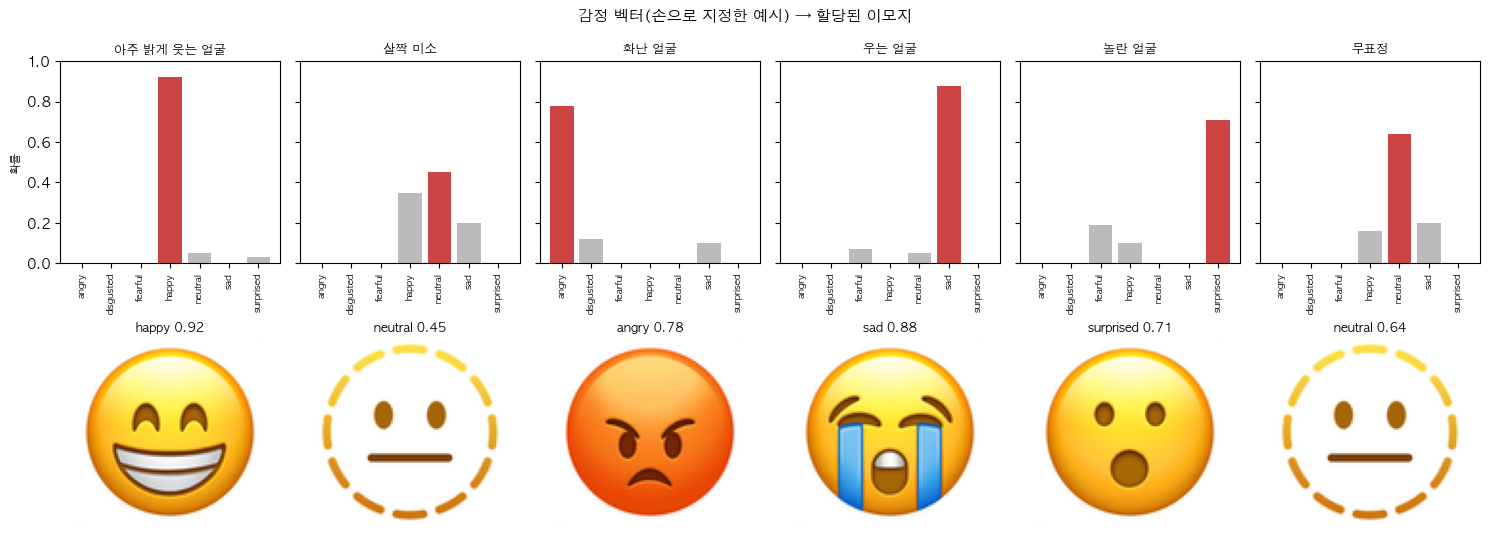

In [12]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4),
                         gridspec_kw={'height_ratios': [1.1, 1]})
for j, (label, d) in enumerate(cases.items()):
    v = np.array([d.get(c, 0.0) for c in FER])
    e, c, cf, _ = assign_emoji(v)

    ax = axes[0][j]
    ax.bar(range(7), v, color=['#c44' if k == v.argmax() else '#bbb' for k in range(7)])
    ax.set_xticks(range(7)); ax.set_xticklabels(FER, rotation=90, fontsize=7)
    ax.set_ylim(0, 1); ax.set_title(label, fontsize=9)
    if j: ax.set_yticklabels([])

    ax = axes[1][j]
    ax.imshow(render(e, 96)); ax.axis('off')
    ax.set_title(f'{c} {cf:.2f}', fontsize=9)

axes[0][0].set_ylabel('확률', fontsize=8)
plt.suptitle('감정 벡터(손으로 지정한 예시) → 할당된 이모지', fontsize=11)
plt.tight_layout(); plt.show()

## 7. 이 파이프라인의 한계 — 확신도 0.28 문제

원본 노트북이 실제 사진(`happy.jpg`)에 대해 출력한 확신도는 **0.28**이었다.
7개 클래스에서 최대값이 0.28이면 나머지에 0.72가 흩어져 있다는 뜻이다.

그런 벡터에서 최대 클래스를 고르는 것이 얼마나 불안정한지 확인한다.

In [13]:
rng = np.random.default_rng(42)
base = np.array([0.13, 0.09, 0.11, 0.28, 0.16, 0.12, 0.11])   # 최대 0.28
base = base / base.sum()
print(f'기준 벡터 (최대 {base.max():.2f} = {FER[base.argmax()]}):')
print('  ' + '  '.join(f'{c} {p:.2f}' for c, p in zip(FER, base)))

flips = []
for noise in [0.02, 0.05, 0.10]:
    changed = 0
    for _ in range(2000):
        v = np.clip(base + rng.normal(0, noise, 7), 1e-6, None); v /= v.sum()
        if FER[v.argmax()] != FER[base.argmax()]: changed += 1
    flips.append({'잡음 표준편차': noise, '클래스가 바뀐 비율': f'{changed/2000*100:.1f}%'})
print(); print(pd.DataFrame(flips).to_string(index=False))

strong = np.array([0.02, 0.02, 0.02, 0.85, 0.05, 0.02, 0.02])
changed = sum(FER[np.clip(strong + rng.normal(0, 0.10, 7), 1e-6, None).argmax()] != 'happy'
              for _ in range(2000))
print(f'\n비교 — 확신도 0.85인 벡터는 같은 잡음(0.10)에서 {changed/2000*100:.1f}% 만 바뀐다')

기준 벡터 (최대 0.28 = happy):
  angry 0.13  disgusted 0.09  fearful 0.11  happy 0.28  neutral 0.16  sad 0.12  surprised 0.11

 잡음 표준편차 클래스가 바뀐 비율
    0.02       0.0%
    0.05       7.1%
    0.10      41.9%

비교 — 확신도 0.85인 벡터는 같은 잡음(0.10)에서 0.0% 만 바뀐다


**확신도가 낮으면 할당 결과가 사실상 임의가 된다.**

이것은 매칭 규칙의 결함이 아니라 **1단계 모델 정확도(0.5628)가 그대로 전파된 것**이다.
파이프라인 전체의 품질 상한은 표정 분류 모델이 결정한다.
이모지를 예쁘게 고르는 규칙을 아무리 다듬어도 이 한계는 넘지 못한다.

## 8. 현재 완성도

| 단계 | 내용 | 상태 |
|---|---|---|
| 1 | 사진 → 7차원 감정 벡터 | ⚠️ **가중치 없음.** 모델은 학습됐으나 `model.save()` 누락으로 Colab 세션과 함께 소실 |
| 2 | 감정 수치화 | ✅ 1단계 softmax 출력이 곧 그것. 원본은 `argmax`로 버리고 있었다 |
| 3 | 벡터 → 이모지 할당 | ✅ **이 노트북에서 완성.** 매핑표 54개 + 강도 + 매칭 규칙 |

1단계만 복구하면 사진을 넣어 이모지가 나오는 완결된 파이프라인이 된다.
복구에 필요한 것: **Kaggle API 토큰 + TensorFlow 설치** (데이터셋 24,400장 재다운로드 후 재학습).

## 9. 결론

### 3단계에서 막혔던 진짜 이유

이모지 변환 버그(`draw.text()` 누락)는 표면적인 원인이었다.
그것을 고쳤어도 **"이모지에 CNN을 돌린다"는 계획 자체가 두 겹으로 불필요했다.**

1. **도메인이 다르다** — 사람 얼굴 사진으로 학습한 모델은 양식화된 이모지에서 신뢰할 수 없다
2. **애초에 모델이 필요 없었다** — 이모지의 감정 레이블은 `emoji_df.csv`의 `name` 칸에 이미 있었다

`iloc[0:105]`가 사람 표정 이모지만 정확히 골라냈다는 사실이 이를 뒷받침한다
(해골·광대·유령·고양이 얼굴은 전부 잘려 있다).
**데이터를 고른 판단은 옳았다. 그 데이터를 어떻게 쓸지에서 갈렸다.**

### 어떻게 진행했어야 했나

| 하려던 것 | 했어야 할 것 |
|---|---|
| 이모지를 이미지로 변환 → CNN 분류 | `emoji_df.csv`의 `name` 키워드로 **대응표 작성** (모델 불필요) |
| 분류 결과에서 감정 수치를 새로 만든다 | 1단계 `predictions[0]` **7차원 벡터를 그대로 사용** (이미 존재) |
| (미정) 이모지 할당 방식 | **최대 클래스 + 확신도↔강도 매칭** (§6) |

### 배운 것

**1. 모델을 붙이기 전에 데이터에 답이 있는지 본다.**
이모지 감정 분류는 CNN·GPU·학습 데이터가 필요한 문제로 보였지만,
실제로는 CSV 한 칸을 읽는 문제였다. 가장 비싼 해법부터 떠올린 것이 3단계에서 막힌 원인이다.

**2. 도메인이 다르면 같은 형식도 같은 데이터가 아니다.**
48×48 그레이스케일이라는 형식이 같다고 해서 사진과 이모지가 같은 입력은 아니다.
형식이 맞는지가 아니라 **분포가 맞는지**를 봐야 했다.

**3. 파이프라인의 품질은 가장 약한 단계가 정한다.**
3단계 매칭 규칙을 아무리 정교하게 만들어도 1단계 확신도가 0.28이면 결과는 임의에 가깝다.
공들일 곳은 뒤가 아니라 앞이었다.

**4. 중간 산출물을 버리지 않는다.**
`argmax` 한 줄이 7차원 벡터를 1개 숫자로 줄였고, 그래서 2단계를 "새로 해야 할 일"로 착각했다.
이미 갖고 있는 것을 파악하는 것이 다음 단계 설계의 출발점이다.

### 남은 가능성 `[미검증]`

- **7개 클래스로는 부족하다.** 이모지 105개 중 51개가 매핑되지 않았다.
  더 세분화된 감정 분류 체계(예: valence–arousal 연속값)를 쓰면 이모지 목록을 더 활용할 수 있다.
- **공통 임베딩 공간.** 사진과 이모지를 같은 벡터 공간에 넣어 최근접 이웃으로 찾는 방식(CLIP 등)이면
  클래스 개수 제약 없이 매칭할 수 있다. 이 환경에서 검증하지 못했다.
- **목표 0(생성)** 은 (사진, 맞춤 이모지) 쌍 데이터가 필요해 여전히 열려 있다.